In [1]:
import numpy as np
import sklearn
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

import scipy.stats
from scipy.stats import norm
from scipy.stats import uniform
from scipy import optimize
from astroML import stats as astroMLstats
from astroML.datasets import fetch_hogg2010test
from sklearn import mixture

In [2]:
#importo i dati
data = np.load('formationchannels.npy')

#li converto in un array monodimensionale con np.newaxis
data[np.newaxis]


#definisco il numero di componenti (DOVREI CICLARE SU QUESTO NUMERO)
N_comp = 10

#inizializzo un vettore per il test AIC
AIC = np.zeros(N_comp)

In [3]:
#alleno il mio modello sui miei dati
for i in range (N_comp):
    clf = mixture.GaussianMixture(n_components=i+1)
    clf.fit(data)
    AIC[i] = clf.aic(data)


#print(clf.means_ , clf.covariances_)
AIC

array([20945.97260859, 20753.49600712, 20083.21382717, 20102.98168132,
       20114.10086335, 20121.19730073, 20129.84939754, 20135.88432366,
       20140.30586435, 20141.81179096])

AIC TEST:

3

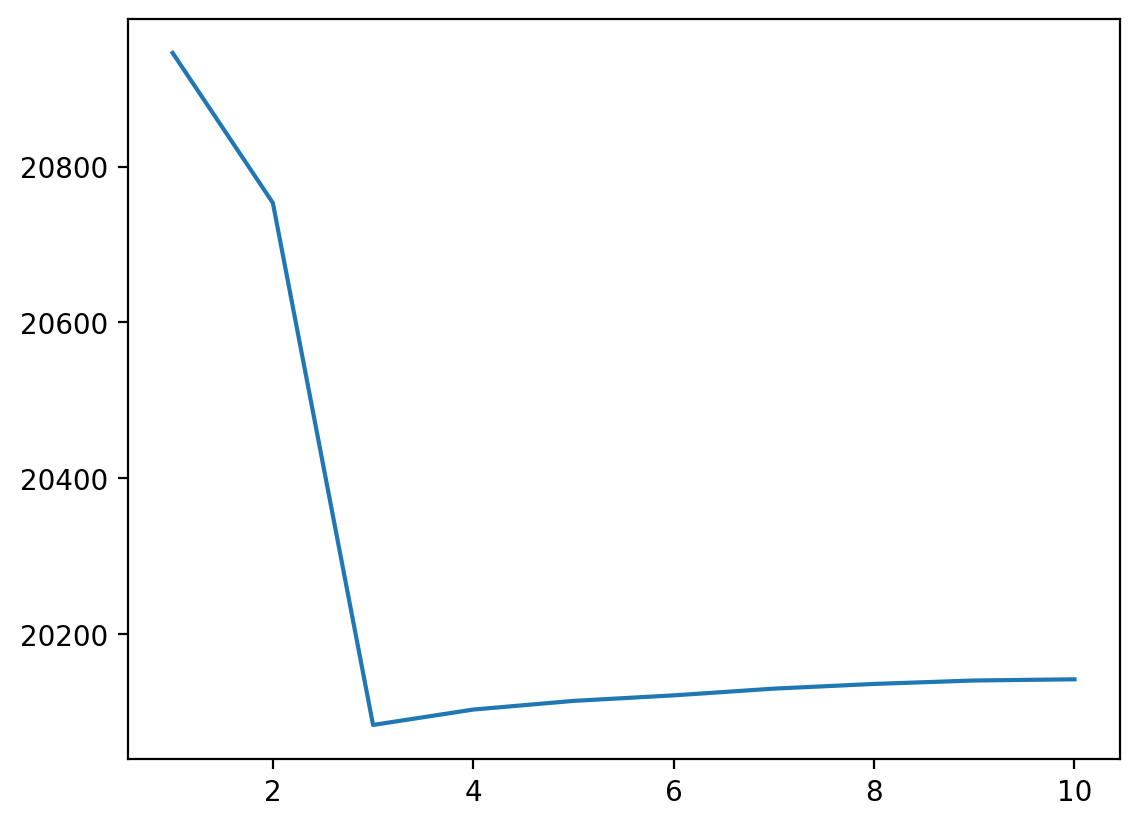

In [4]:
N = np.linspace(1,N_comp , N_comp)

#plot AIC in function of N
plt.plot(N,AIC)
min_index = np.where(AIC == min(AIC))

#the minimum is the best!
index = int(N[min_index[0][0]])
index

Creo plot con miglior numero di componenti gaussiane

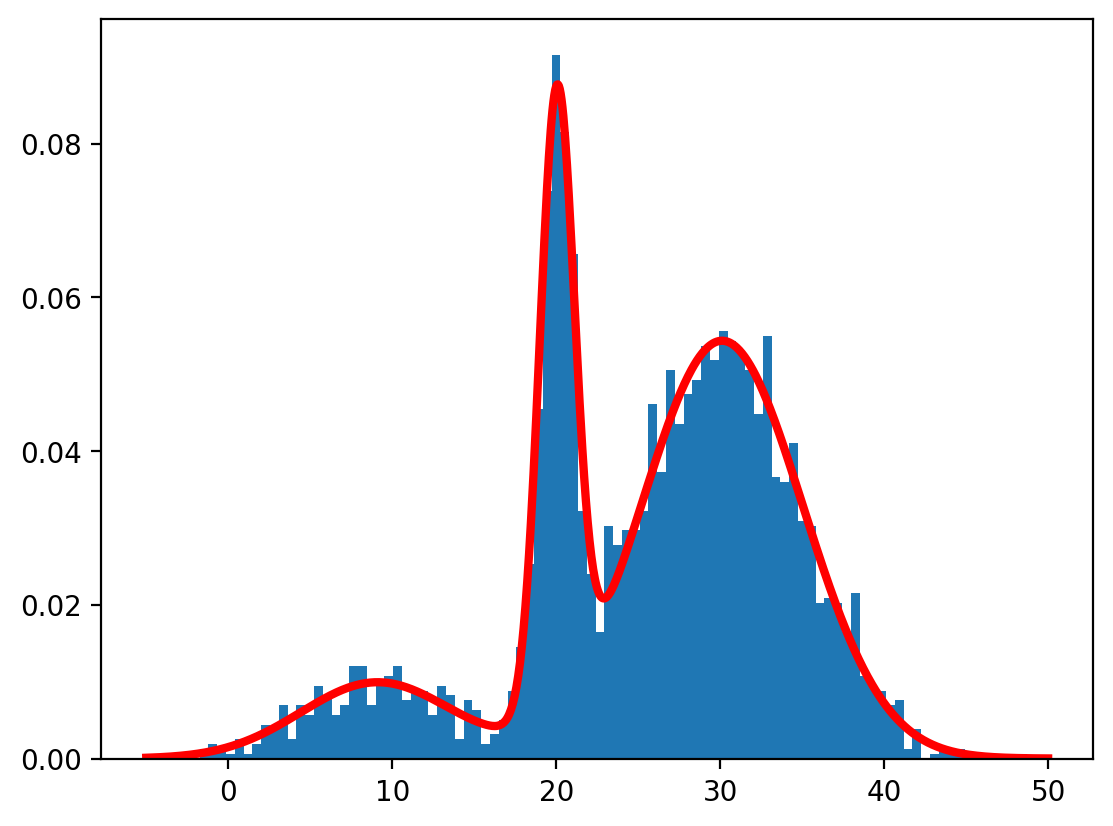

In [5]:
#rappresento i miei dati in un istogramma
plt.hist(data, bins = 100, density = True)

#creo i grafici delle ditribuzioni gaussiane con cui voglio plottare il mio grafico
x = np.linspace(-5,50, 1000)
gauss = np.zeros((index , 1000))
Norm_tot= np.zeros(1000)

clf = mixture.GaussianMixture(n_components=index)
clf.fit(data)

#plotto tutte le distribuzioni ciclando sul numero di componenti gaussiane
for i in range (index):
    
    #sommo ogni gaussiana con il proprio peso
    Norm_tot += clf.weights_[i]*norm.pdf(x , clf.means_[i][0], np.sqrt(clf.covariances_[i][0]))

#plotto la somma delle gaussiane
plt.plot(x, Norm_tot, linewidth=3, color = 'r')
plt.show()

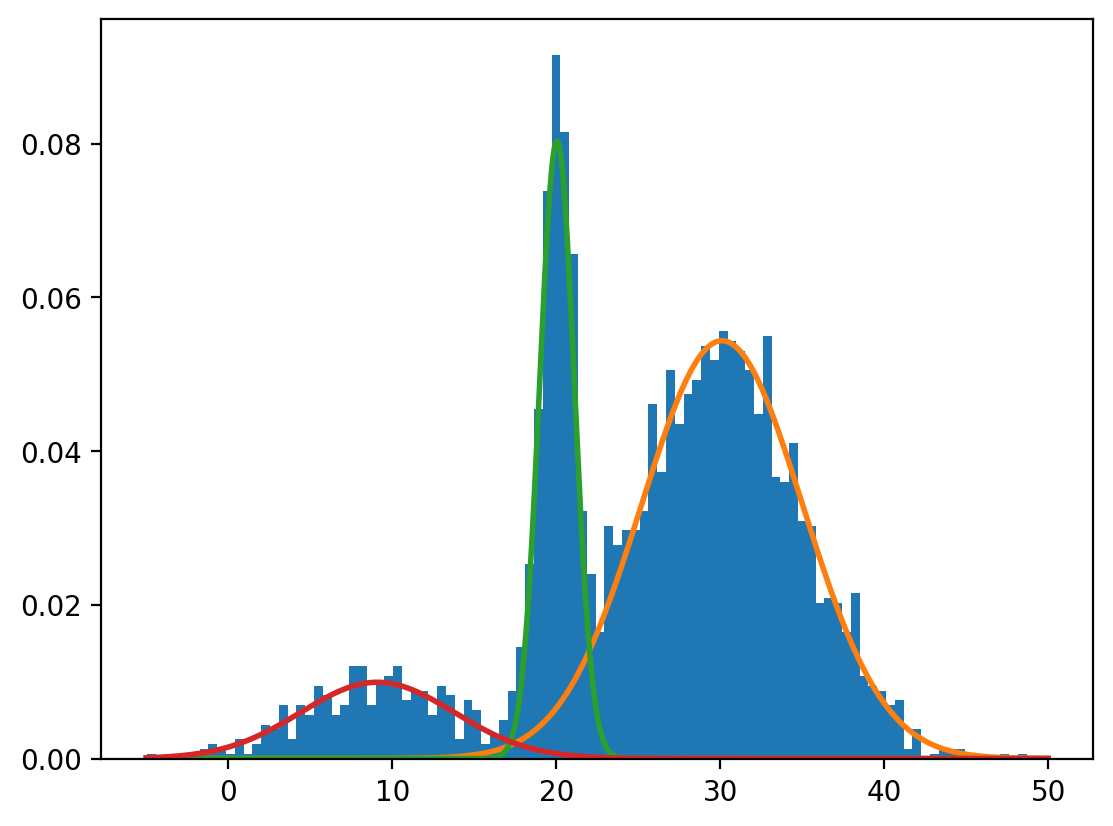

In [6]:
plt.hist(data, bins = 100, density = True)

for i in range(index):
    #riempio un array con ogni gaussiana
    gauss[i , :] =  clf.weights_[i]*norm.pdf(x , clf.means_[i][0], np.sqrt(clf.covariances_[i][0]))
    plt.plot(x, gauss[i, :], linewidth=2)

plt.show()

 ## Estimation of kernel density using cross validation

In [27]:
# Complete and Execute this cell to determine the bandwidth
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
from scipy import stats

bwrange = np.linspace(0.01,1.0, 30) # Test 30 bandwidths from 0.1 to 1.0
print(bwrange)
K = 10 # Do 5-fold cross validation
grid = GridSearchCV(KernelDensity(), {'bandwidth': bwrange}, cv= K) # Try each bandwidth with K-folds
grid.fit(data.reshape(-1,1)) #Fit the data that we started the lecture with.
h_opt = grid.best_params_['bandwidth']

bins = np.linspace(min(data)-1, max(data) + 1, 130)

binwidth = bins[1] - bins[0]
x_grid = np.linspace(min(data)-1, max(data) + 1, len(data))
y_plot = binwidth * stats.norm.pdf(x_grid, data, h_opt)
y_plot /= (binwidth * len(data))

[0.01       0.04413793 0.07827586 0.11241379 0.14655172 0.18068966
 0.21482759 0.24896552 0.28310345 0.31724138 0.35137931 0.38551724
 0.41965517 0.4537931  0.48793103 0.52206897 0.5562069  0.59034483
 0.62448276 0.65862069 0.69275862 0.72689655 0.76103448 0.79517241
 0.82931034 0.86344828 0.89758621 0.93172414 0.96586207 1.        ]


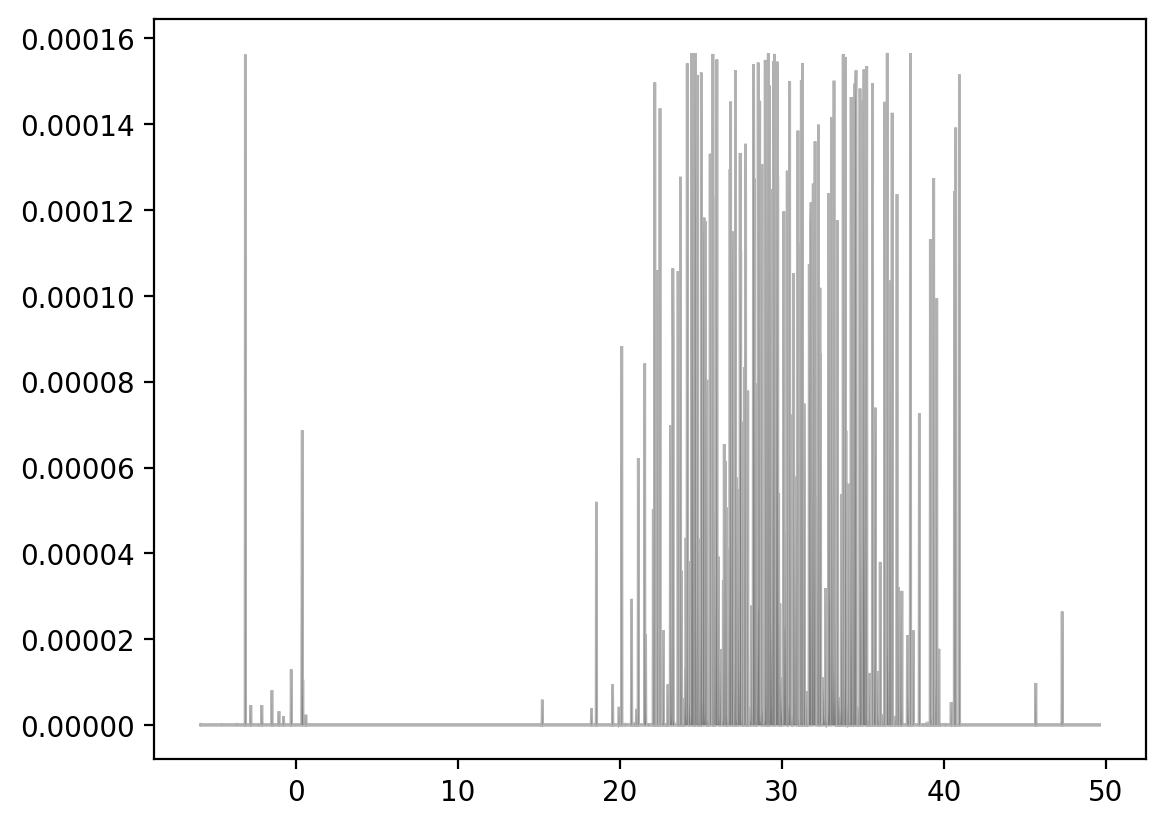

In [29]:
plt.fill(x_grid, y_plot, ec='k', lw=1, fc='k', alpha=0.3)